# Part I - Exploratory Data Analysis of the Ford GoBike Bike-Sharing Dataset

## by Soham Patra

## Introduction

The Ford GoBike dataset contains information about individual bicycle trips made through a bike-sharing system operating in the San Francisco Bay Area. Each record represents a single trip and includes trip duration, start and end times, station information, user type, gender, and birth year.

The objective of this exploration is to understand rider behavior, identify usage patterns, and examine how trip duration varies with factors such as user type, age, gender, and time of day.

## Preliminary Wrangling

In [32]:
# import all packages and set plots to be embedded inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

sns.set_style("whitegrid")

> Load in your dataset and describe its properties through the questions below. Try and motivate your exploration goals through this section.

> Note that the collective size of all your files in the current worksapce **must not exceed 1 GB** in total. 


In [33]:
# ---------------------------------------------
# Helper Functions
# ---------------------------------------------

def start_plot(figsize=(10,5)):
    """
    Create a figure with a consistent size.
    """
    plt.figure(figsize=figsize)


def format_plot(title, xlabel, ylabel):
    """
    Apply common formatting to plots.
    """
    plt.title(title, fontsize=14)
    plt.xlabel(xlabel, fontsize=12)
    plt.ylabel(ylabel, fontsize=12)
    plt.tight_layout()

In [34]:
# Load the Ford GoBike dataset
df = pd.read_csv('201902-fordgobike-tripdata.csv')
df.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.1450,2019-03-01 08:01:55.9750,21.0,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13.0,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
1,42521,2019-02-28 18:53:21.7890,2019-03-01 06:42:03.0560,23.0,The Embarcadero at Steuart St,37.791464,-122.391034,81.0,Berry St at 4th St,37.775880,-122.393170,2535,Customer,NaN,NaN,No
2,61854,2019-02-28 12:13:13.2180,2019-03-01 05:24:08.1460,86.0,Market St at Dolores St,37.769305,-122.426826,3.0,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.0100,2019-03-01 04:02:36.8420,375.0,Grove St at Masonic Ave,37.774836,-122.446546,70.0,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.5490,2019-03-01 00:20:44.0740,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes


In [35]:
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 183412 entries, 0 to 183411
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   duration_sec             183412 non-null  int64  
 1   start_time               183412 non-null  object 
 2   end_time                 183412 non-null  object 
 3   start_station_id         183215 non-null  float64
 4   start_station_name       183215 non-null  object 
 5   start_station_latitude   183412 non-null  float64
 6   start_station_longitude  183412 non-null  float64
 7   end_station_id           183215 non-null  float64
 8   end_station_name         183215 non-null  object 
 9   end_station_latitude     183412 non-null  float64
 10  end_station_longitude    183412 non-null  float64
 11  bike_id                  183412 non-null  int64  
 12  user_type                183412 non-null  object 
 13  member_birth_year        175147 non-null  float64
 14  memb

(None, (183412, 16))

In [36]:
print("Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

Shape: (183412, 16)

Column Names:
Index(['duration_sec', 'start_time', 'end_time', 'start_station_id',
       'start_station_name', 'start_station_latitude',
       'start_station_longitude', 'end_station_id', 'end_station_name',
       'end_station_latitude', 'end_station_longitude', 'bike_id', 'user_type',
       'member_birth_year', 'member_gender', 'bike_share_for_all_trip'],
      dtype='object')

Data Types:
duration_sec                 int64
start_time                  object
end_time                    object
start_station_id           float64
start_station_name          object
start_station_latitude     float64
start_station_longitude    float64
end_station_id             float64
end_station_name            object
end_station_latitude       float64
end_station_longitude      float64
bike_id                      int64
user_type                   object
member_birth_year          float64
member_gender               object
bike_share_for_all_trip     object
dtype: object

Missin

In [37]:
df.describe()

,duration_sec,start_station_id,start_station_latitude,start_station_longitude,end_station_id,end_station_latitude,end_station_longitude,bike_id,member_birth_year
count,183412.000000,183215.000000,183412.000000,183412.000000,183215.000000,183412.000000,183412.000000,183412.000000,175147.000000
mean,726.078435,138.590427,37.771223,-122.352664,136.249123,37.771427,-122.352250,4472.906375,1984.806437
std,1794.389780,111.778864,0.099581,0.117097,111.515131,0.099490,0.116673,1664.383394,10.116689
min,61.000000,3.000000,37.317298,-122.453704,3.000000,37.317298,-122.453704,11.000000,1878.000000
25%,325.000000,47.000000,37.770083,-122.412408,44.000000,37.770407,-122.411726,3777.000000,1980.000000
50%,514.000000,104.000000,37.780760,-122.398285,100.000000,37.781010,-122.398279,4958.000000,1987.000000
75%,796.000000,239.000000,37.797280,-122.286533,235.000000,37.797320,-122.288045,5502.000000,1992.000000
max,85444.000000,398.000000,37.880222,-121.874119,398.000000,37.880222,-121.874119,6645.000000,2001.000000


In [38]:

# Create a copy of the original dataset
bike = df.copy()

# Convert start and end time to datetime
bike['start_time'] = pd.to_datetime(bike['start_time'])
bike['end_time'] = pd.to_datetime(bike['end_time'])

# Remove rows with missing values
bike = bike.dropna()

# Remove duplicate rows
bike = bike.drop_duplicates()

# Convert station IDs into integers
bike['start_station_id'] = bike['start_station_id'].astype(int)
bike['end_station_id'] = bike['end_station_id'].astype(int)

In [39]:
print(bike.shape)
bike.head()

(174952, 16)


,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86,Market St at Dolores St,37.769305,-122.426826,3,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375,Grove St at Masonic Ave,37.774836,-122.446546,70,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7,Frank H Ogawa Plaza,37.804562,-122.271738,222,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93,4th St at Mission Bay Blvd S,37.770407,-122.391198,323,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No


In [40]:
bike['age'] = 2019 - bike['member_birth_year']

In [41]:
bike['month'] = bike['start_time'].dt.month_name()

In [42]:
bike['day'] = bike['start_time'].dt.day_name()

In [43]:
bike['hour'] = bike['start_time'].dt.hour

In [44]:
bike.head()

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,end_station_longitude,bike_id,user_type,member_birth_year,member_gender,bike_share_for_all_trip,age,month,day,hour
0,52185,2019-02-28 17:32:10.145,2019-03-01 08:01:55.975,21,Montgomery St BART Station (Market St at 2nd St),37.789625,-122.400811,13,Commercial St at Montgomery St,37.794231,-122.402923,4902,Customer,1984.0,Male,No,35.0,February,Thursday,17
2,61854,2019-02-28 12:13:13.218,2019-03-01 05:24:08.146,86,Market St at Dolores St,37.769305,-122.426826,3,Powell St BART Station (Market St at 4th St),37.786375,-122.404904,5905,Customer,1972.0,Male,No,47.0,February,Thursday,12
3,36490,2019-02-28 17:54:26.010,2019-03-01 04:02:36.842,375,Grove St at Masonic Ave,37.774836,-122.446546,70,Central Ave at Fell St,37.773311,-122.444293,6638,Subscriber,1989.0,Other,No,30.0,February,Thursday,17
4,1585,2019-02-28 23:54:18.549,2019-03-01 00:20:44.074,7,Frank H Ogawa Plaza,37.804562,-122.271738,222,10th Ave at E 15th St,37.792714,-122.248780,4898,Subscriber,1974.0,Male,Yes,45.0,February,Thursday,23
5,1793,2019-02-28 23:49:58.632,2019-03-01 00:19:51.760,93,4th St at Mission Bay Blvd S,37.770407,-122.391198,323,Broadway at Kearny,37.798014,-122.405950,5200,Subscriber,1959.0,Male,No,60.0,February,Thursday,23


### What is the structure of your dataset?

>The original dataset contains 183,412 bike trips and 16 variables. The variables include trip duration, trip start and end times, station information, user type, gender, birth year, and bike sharing status. During preprocessing, missing values and duplicate records were removed to improve data quality before performing the analysis.

### What is/are the main feature(s) of interest in your dataset?

> The main features of interest are trip duration, user type, rider age, gender, and the time when trips occur. These variables help understand rider behavior and identify factors that influence bike usage.

### What features in the dataset do you think will help support your investigation into your feature(s) of interest?

> The investigation will mainly use trip duration, user type, age, gender, hour of the day, day of the week, start station, and end station. These variables provide useful insights into travel patterns and rider characteristics.

## Univariate Exploration

### Question

How are trip durations distributed among bike trips?

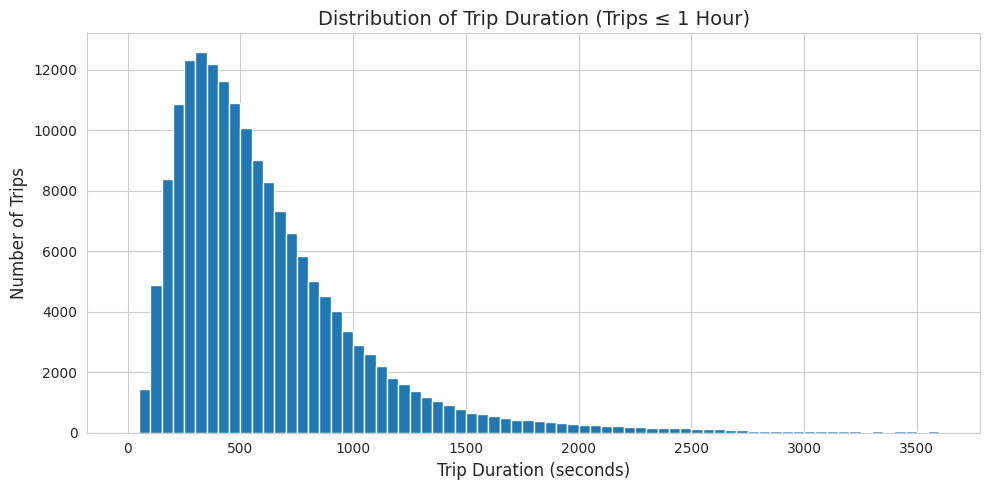

In [45]:
start_plot()
bike_duration = bike[bike['duration_sec'] <= 3600]

bins = np.arange(0, 3600 + 50, 50)

plt.hist(bike_duration['duration_sec'], bins=bins)

format_plot(
    "Distribution of Trip Duration (Trips ≤ 1 Hour)",
    "Trip Duration (seconds)",
    "Number of Trips"
)

plt.show()

### Observation
Most trips last between approximately 300 and 900 seconds.
The distribution is highly right-skewed, indicating that only a few trips have very long durations.

In [46]:
bike['duration_sec'].describe()

count    174952.000000
mean        704.002744
std        1642.204905
min          61.000000
25%         323.000000
50%         510.000000
75%         789.000000
max       84548.000000
Name: duration_sec, dtype: float64

### Question

What is the distribution of bike trips by user type?

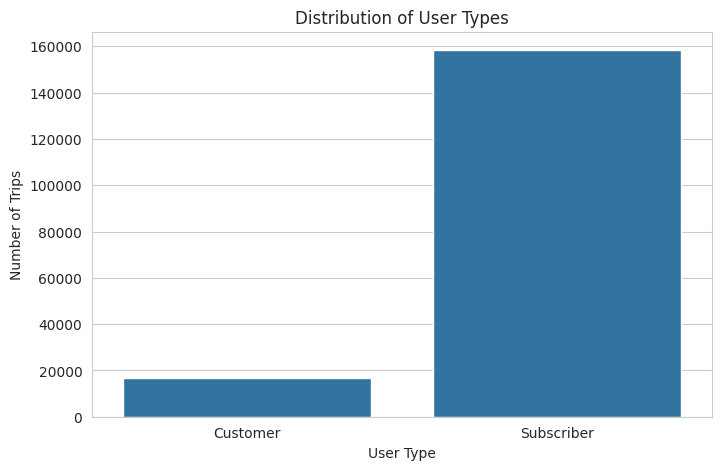

In [47]:
start_plot(figsize=(8,5))

sns.countplot(data=bike, x='user_type')

plt.title('Distribution of User Types')
plt.xlabel('User Type')
plt.ylabel('Number of Trips')

plt.show()

### Observation

Subscribers account for the majority of bike trips, while Customers represent a much smaller proportion. This suggests that regular members are the primary users of the bike-sharing system.

### Discuss the distribution(s) of your variable(s) of interest. Were there any unusual points? Did you need to perform any transformations?

> The distribution of trip duration is strongly right-skewed. Most bike trips last between approximately 300 and 900 seconds, while only a small number of trips are much longer. Because a few extremely long trips stretch the distribution, the visualization was limited to trips of one hour or less to better display the overall pattern.

### Of the features you investigated, were there any unusual distributions? Did you perform any operations on the data to tidy, adjust, or change the form of the data? If so, why did you do this?

> The dataset contained missing values in station information, member birth year, and member gender. These records were removed during the data cleaning process to improve the quality of the analysis. The start and end time columns were converted to datetime format, and additional features such as rider age, hour of the day, day of the week, and month were created to support further exploration. Extremely long trip durations were not removed from the dataset, but they were excluded from one visualization so that the overall distribution could be displayed more clearly.

## Bivariate Exploration

### Question

Is there a relationship between rider age and trip duration?

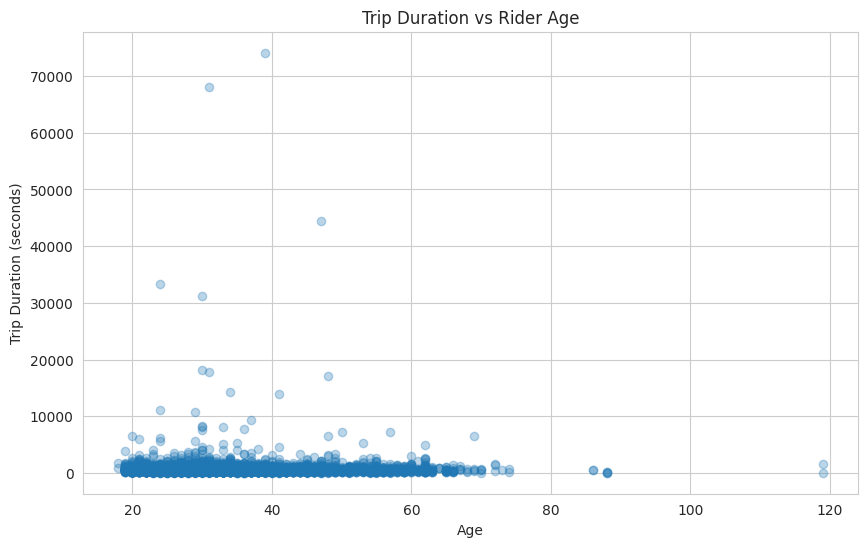

In [48]:
plt.figure(figsize=(10,6))

sample = bike.sample(5000, random_state=42)

plt.scatter(sample['age'], sample['duration_sec'], alpha=0.3)

plt.xlabel('Age')
plt.ylabel('Trip Duration (seconds)')
plt.title('Trip Duration vs Rider Age')

plt.show()

### Observation

The scatter plot indicates that most riders are between 20 and 45 years old. Trip duration does not show a strong relationship with age, although a few longer trips are visible.

### Question

How does trip duration differ between Subscribers and Customers?

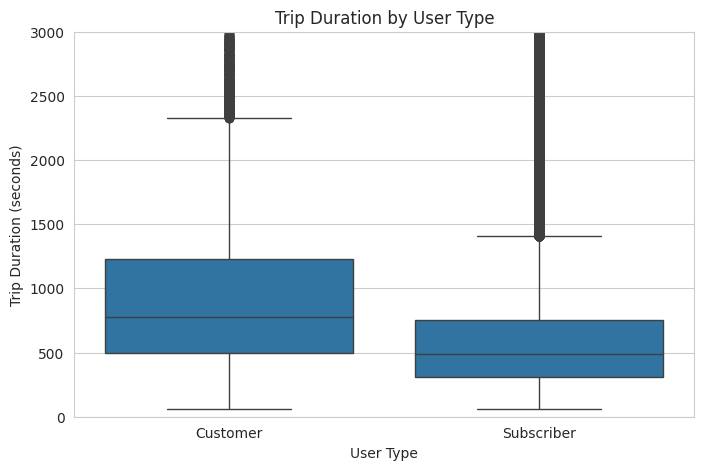

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(data=bike, x='user_type', y='duration_sec')

plt.ylim(0,3000)

plt.title('Trip Duration by User Type')

plt.xlabel('User Type')

plt.ylabel('Trip Duration (seconds)')

plt.show()

### Observation

Customers generally take longer trips than Subscribers. Subscribers have shorter and more consistent trip durations, while Customers exhibit greater variability.

### Question

What is the correlation between the numerical variables (trip duration, rider age, and trip start hour)?

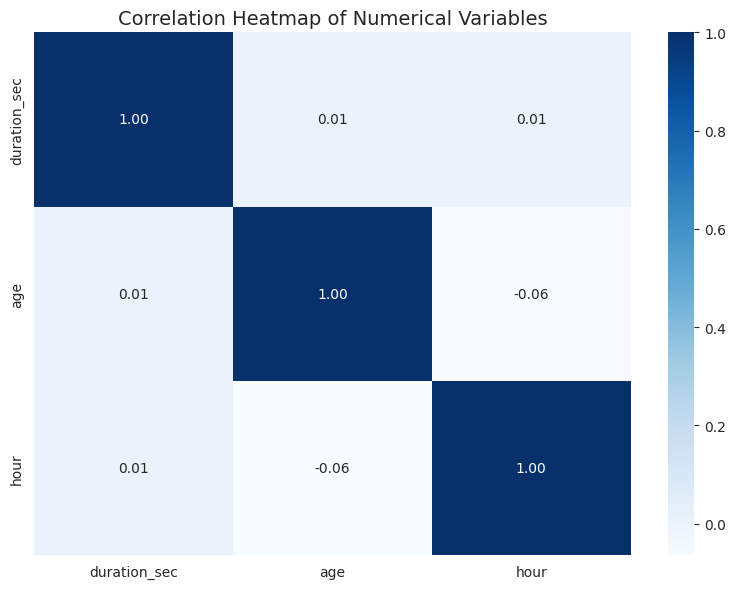

In [50]:
# Plot a correlation heatmap for numerical variables

start_plot(figsize=(8,6))

corr = bike[['duration_sec', 'age', 'hour']].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='Blues',
    fmt='.2f'
)

format_plot(
    "Correlation Heatmap of Numerical Variables",
    "",
    ""
)

plt.show()

### Question

What is the correlation between the numerical variables (trip duration, rider age, and trip start hour)?

### Talk about some of the relationships you observed in this part of the investigation. How did the feature(s) of interest vary with other features in the dataset?

> The bivariate analysis shows that trip duration varies more noticeably with user type than with rider age. The scatter plot indicates that most riders are between 20 and 45 years old, with no strong relationship between age and trip duration. The box plot shows that Customers generally have longer trip durations and greater variability than Subscribers, while Subscribers tend to take shorter and more consistent trips. The heatmap also indicates that the numerical variables have only weak correlations with each other.

### Did you observe any interesting relationships between the other features (not the main feature(s) of interest)?

> One interesting observation is that Subscribers make the majority of trips but generally have shorter ride durations, whereas Customers make fewer trips but tend to ride for longer periods. Rider age appears to have only a limited effect on trip duration compared with user type, suggesting that membership status is a stronger factor influencing riding behavior.

## Multivariate Exploration

### Question

How does user type influence the relationship between rider age and trip duration?

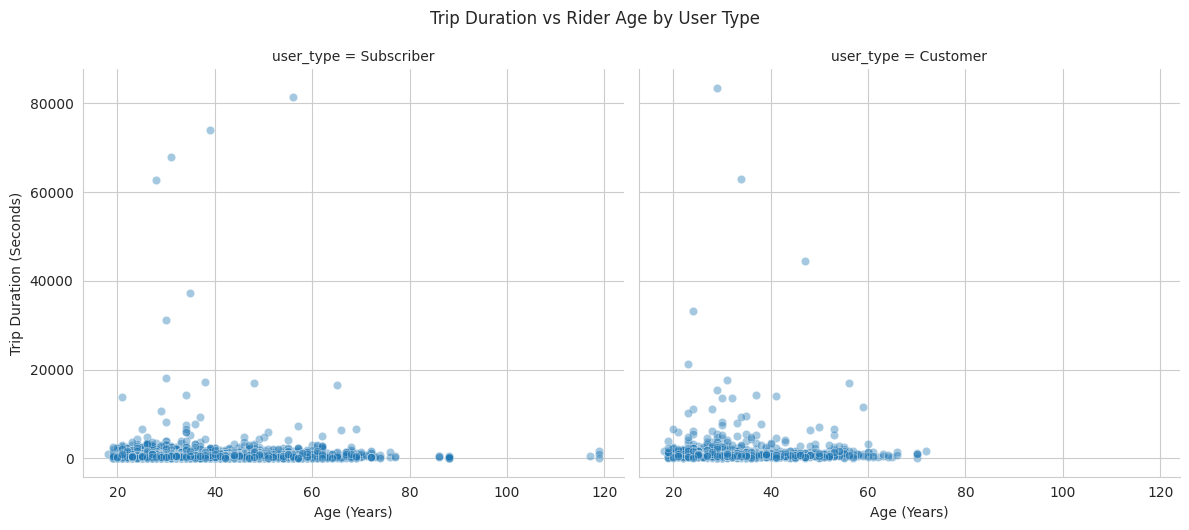

In [51]:
# Facet Plot: Trip Duration vs Age by User Type

g = sns.FacetGrid(
    bike.sample(12000, random_state=42),
    col='user_type',
    height=5,
    aspect=1.2
)

g.map_dataframe(
    sns.scatterplot,
    x='age',
    y='duration_sec',
    alpha=0.4
)

g.set_axis_labels("Age (Years)", "Trip Duration (Seconds)")
g.fig.suptitle("Trip Duration vs Rider Age by User Type", y=1.05)

plt.show()

### Observation

Subscribers consistently take shorter trips across most age groups, while Customers tend to have longer and more variable trip durations.

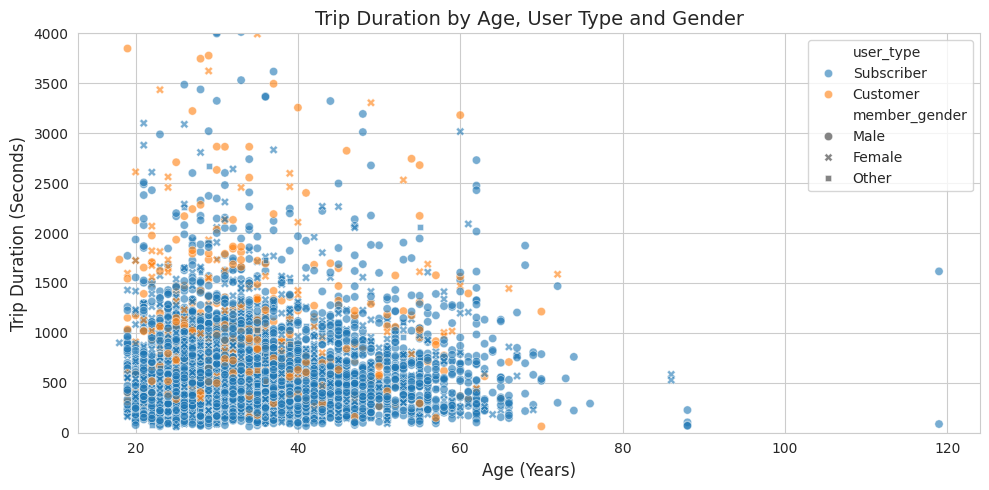

In [52]:
start_plot()

sample = bike.sample(6000, random_state=42)

sns.scatterplot(
    data=sample,
    x='age',
    y='duration_sec',
    hue='user_type',
    style='member_gender',
    alpha=0.6
)

plt.ylim(0,4000)

format_plot(
    "Trip Duration by Age, User Type and Gender",
    "Age (Years)",
    "Trip Duration (Seconds)"
)
plt.show()

### Talk about some of the relationships you observed in this part of the investigation. Were there features that strengthened each other in terms of looking at your feature(s) of interest?

> The multivariate analysis provides a deeper understanding of how multiple variables interact. User type strengthens the relationship between rider age and trip duration, with Subscribers consistently taking shorter trips than Customers across most age groups. Adding gender to the visualization shows similar riding patterns between male and female riders, while user type remains the strongest factor affecting trip duration.

### Were there any interesting or surprising interactions between features?

> A notable finding is that although Subscribers make most of the trips, Customers generally spend more time riding. Rider age does not significantly influence trip duration when user type is considered. Gender also shows relatively small differences compared with the effect of user type, indicating that membership status is the most influential variable among those explored.

## Conclusions
> The exploratory analysis of the Ford GoBike dataset produced several key findings:

- The majority of bike trips last less than 15 minutes.
- Subscribers account for most rides in the bike-sharing system.
- Customers generally take longer trips than Subscribers.
- Rider age has only a weak relationship with trip duration.
- User type is the strongest factor influencing trip duration.
- The multivariate analysis confirmed that membership status has a greater impact on riding behavior than age or gender.

Overall, the Ford GoBike dataset provides valuable insights into rider behavior and demonstrates how exploratory data visualization can uncover meaningful patterns in transportation data.